# **Нелинейные модели против южной погоды**

## **Часть 1. Работа с базовой моделью**

### Вводная информация

##### Описание проекта

Изучить базовую модель и провести исследование направленное на улучшение базовой модели прогнозирования спроса на прокат велосипедов для компании BikeSouth

##### Тип задачи

Задача регрессии с использованием нелинейных моделей KNN и решающее дерево

##### Цель модели

Прогнозирование почасового спроса на велосипеды на основе имеющихся данных об аренде и погодных условиях

##### Задачи исследования

1. Исследовать базовую модель линейной регрессии и метрики к ней
2. Провести подготовку данных для нелинейных моделей
3. Провести обучение и подбор гиперпараметров моделей  KNN и решающее дерево
4. Рассчитать метрики к моделям и выбрать лучшую модель
5. Проверить лучшую модель на тестовой выборке
6. Подготовить выводы для заказчика и модель для использования

##### Описание исходных данных

Заказчик предоставил два датасета: для обучения и для тестирования модели. Датасеты содержат историческую информацию о погодных условиях и спросе на аренду велосипедов

##### Этапы исследования

1. Загрузка и изучение базовой модели, предоставленной заказчиком
2. Загрузка и исследовательский анализ данных
3. Предобработка данных
4. Обучение экспериментальных моделей
5. Подбор гиперпараметров
6. Изучение метрик полученных моделей и выбор лучшей модели
7. Тестирование лучшей модели на тестовой выборке
8. Подготовка выводов и артефактов

### Подготовка библиотек и среды разработки

In [1]:
# Соберем все необходимые зависимости 

requirements = """
anyio==4.12.1
appnope==0.1.4
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
arrow==1.4.0
asttokens==3.0.1
async-lru==2.1.0
attrs==25.4.0
babel==2.17.0
beautifulsoup4==4.14.3
bleach==6.3.0
certifi==2026.1.4
cffi==2.0.0
charset-normalizer==3.4.4
colorlog==6.10.1
comm==0.2.3
contourpy==1.3.3
cycler==0.12.1
debugpy==1.8.19
decorator==5.2.1
defusedxml==0.7.1
dill==0.4.1
executing==2.2.1
fastjsonschema==2.21.2
fonttools==4.61.1
fqdn==1.5.1
h11==0.16.0
httpcore==1.0.9
httpx==0.28.1
idna==3.11
ipykernel==7.1.0
ipython==9.9.0
ipython_pygments_lexers==1.1.1
ipywidgets==8.1.8
isoduration==20.11.0
jedi==0.19.2
Jinja2==3.1.6
joblib==1.5.3
json5==0.13.0
jsonpointer==3.0.0
jsonschema==4.26.0
jsonschema-specifications==2025.9.1
jupyter==1.1.1
jupyter-console==6.6.3
jupyter-events==0.12.0
jupyter-lsp==2.3.0
jupyter_client==8.8.0
jupyter_core==5.9.1
jupyter_server==2.17.0
jupyter_server_terminals==0.5.4
jupyterlab==4.5.2
jupyterlab_pygments==0.3.0
jupyterlab_server==2.28.0
jupyterlab_widgets==3.0.16
kiwisolver==1.4.9
lark==1.3.1
Mako==1.3.10
MarkupSafe==3.0.3
matplotlib==3.10.8
matplotlib-inline==0.2.1
mistune==3.2.0
nbclient==0.10.4
nbconvert==7.16.6
nbformat==5.10.4
nest-asyncio==1.6.0
notebook==7.5.2
notebook_shim==0.2.4
numpy==1.26.4
optuna==4.8.0
packaging==25.0
pandas==3.0.0
pandocfilters==1.5.1
parso==0.8.5
pexpect==4.9.0
phik==0.12.5
pillow==12.1.0
platformdirs==4.5.1
prometheus_client==0.24.1
prompt_toolkit==3.0.52
psutil==7.2.1
ptyprocess==0.7.0
pure_eval==0.2.3
pycparser==2.23
Pygments==2.19.2
pyparsing==3.3.2
python-dateutil==2.9.0.post0
python-json-logger==4.0.0
PyYAML==6.0.3
pyzmq==27.1.0
referencing==0.37.0
requests==2.32.5
rfc3339-validator==0.1.4
rfc3986-validator==0.1.1
rfc3987-syntax==1.1.0
rpds-py==0.30.0
scikit-learn==1.6.1
scipy==1.17.0
seaborn==0.13.2
Send2Trash==2.1.0
setuptools==80.9.0
six==1.17.0
soupsieve==2.8.1
SQLAlchemy==2.0.49
stack-data==0.6.3
terminado==0.18.1
threadpoolctl==3.6.0
tinycss2==1.4.0
tornado==6.5.4
tqdm==4.67.3
traitlets==5.14.3
typing_extensions==4.15.0
tzdata==2025.3
uri-template==1.3.0
urllib3==2.6.3
wcwidth==0.2.14
webcolors==25.10.0
webencodings==0.5.1
websocket-client==1.9.0
widgetsnbextension==4.0.15
"""

In [2]:
# Запишем зависимости в requirements.txt

with open("requirements.txt", "w") as f:
    f.write(requirements)

In [3]:
# Установим зависимости

!pip install -r requirements.txt

In [4]:
# Зафиксируем константы

RANDOM_STATE = 42
N_FOLDS = 5

In [5]:
# Импортируем все необходимые библиотеки

import ssl
import urllib.request
import os
import io
import joblib
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

### Подготовка и загрузка модели и данных для исследования

In [6]:
# Напишем функцию для загрузки файла локально или с сервера

def load_data(local_path, server_path):
    try:
        # Сначала пробуем локальный путь
        print(f"Пробуем загрузить из локального пути: {local_path}")
        df = pd.read_csv(local_path)
        print("Данные загружены из локального файла")
        return df
    
    except FileNotFoundError:
        # Если локальный файл не найден, пробуем серверный
        try:
            df = pd.read_csv(server_path)
            print("Данные загружены с сервера")
            return df
        except FileNotFoundError:
            print("Файл не найден ни в локально, ни на сервере")
            return None
        except Exception as e:
            print(f"Ошибка при загрузке с сервера: {e}")
            return None
    
    except Exception as e:
        print(f"Ошибка при загрузке из локального файла: {e}")
        return None

In [7]:
# Подготовим функционал по работе с неподтвержденными сертификатами

try:
    # Создаем небезопасный контекст
    ssl_context = ssl._create_unverified_context()
except AttributeError:
    # Альтернативный метод, если _create_unverified_context не работает
    ssl_context = ssl.SSLContext(ssl.PROTOCOL_TLS_CLIENT)
    ssl_context.check_hostname = False
    ssl_context.verify_mode = ssl.CERT_NONE

# Создаем opener с нашим контекстом
https_handler = urllib.request.HTTPSHandler(context=ssl_context)
opener = urllib.request.build_opener(https_handler)
urllib.request.install_opener(opener)

In [8]:
# Путь к готовому обученному пайплайну

local_linreg_pipe = '../datasets/baseline_linear_regression_pipeline.pkl'
server_linreg_pipe = 'https://code.s3.yandex.net/data-scientist/baseline_linear_regression_pipeline.pkl'

In [9]:
# Путь к файлу с обучающим датасетом

local_bike_train= '../datasets/ds_s14_train_data.csv'
server_bike_train = 'https://code.s3.yandex.net/datasets/ds_s14_train_data.csv'

In [10]:
# Путь к файлу с датасетом с тестовыми данными

local_bike_test = '../datasets/ds_s14_test_data.csv'
server_bike_test = 'https://code.s3.yandex.net/datasets/ds_s14_test_data.csv'

In [11]:
# Загружаем данные в датасеты

df_train = load_data(local_bike_train, server_bike_train)
df_test = load_data(local_bike_test, server_bike_test)

Пробуем загрузить из локального пути: ../datasets/ds_s14_train_data.csv
Данные загружены из локального файла
Пробуем загрузить из локального пути: ../datasets/ds_s14_test_data.csv
Данные загружены из локального файла


In [12]:
# Загружаем модель с сервера (либо можно изменить на использование локального файла)

# Скачиваем файл
response = requests.get(server_linreg_pipe)

linreg_model = joblib.load(io.BytesIO(response.content))

In [13]:
# Выведем информацию о загруженных данных для обучения

df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   str    
 9   Holiday                   7008 non-null   str    
 10  Functioning Day           7008 non-null   str    
 11  Time_Period_Evening       7008 non-null   bool   
 12  Time_Period_Late Evening  7008 non-null   bool   
 13  Time_Period_Morning       7008 non-null   bool   
 14  Time_Period_Night  

In [14]:
# Выведем информацию о тестовом датасете

df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               1752 non-null   float64
 1   Humidity(%)               1680 non-null   float64
 2   Wind speed (m/s)          1700 non-null   float64
 3   Visibility (10m)          1680 non-null   float64
 4   Dew point temperature     1752 non-null   float64
 5   Solar Radiation (MJ/m2)   1700 non-null   float64
 6   Rainfall(mm)              1688 non-null   float64
 7   Snowfall (cm)             1691 non-null   float64
 8   Seasons                   1752 non-null   str    
 9   Holiday                   1752 non-null   str    
 10  Functioning Day           1752 non-null   str    
 11  Time_Period_Evening       1752 non-null   bool   
 12  Time_Period_Late Evening  1752 non-null   bool   
 13  Time_Period_Morning       1752 non-null   bool   
 14  Time_Period_Night  

In [15]:
# Выведем информацию о модели

print(linreg_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Temperature', 'Humidity(%)',
                                                   'Wind speed (m/s)',
                                                   'Visibility (10m)',
                                                   'Dew point temperature',
                                                   'Solar Radiation (MJ/m2)',
                                                   'Rainfall(mm)',
                                                   'Snowfall (cm)']),
                                                 ('

Выводы: 

1. Для работы мы получили два датасета: для обучения и для тестирования модели, а также готовую модель линейной регрессии, на которой заказчик проводил предсказания.
2. Датасет для тестов модели составляет примерно 20% от датасета для обучения, что является хорошим показателем.
3. Модель представляет собой пайплайн, который содержит предобработку данных, и, собственно, саму модель линейной регрессии для предсказания значений целевой переменной.
4. Данные пригодны для дальнейшего выполнения задачи

### Исследование базовой модели

In [16]:
# Для обучения полученной модели и расчета метрик разделим тестовую и обучающую выборки на признаки и целевую переменную

X_train = df_train.drop('Rented Bike Count', axis=1)
y_train = df_train['Rented Bike Count']

X_test = df_test.drop('Rented Bike Count', axis=1)
y_test = df_test['Rented Bike Count']

In [17]:
# Применим загруженную модель к тестовому датасету

y_test_pred = linreg_model.predict(X_test)

In [18]:
# Для оценки моделей посчитаем метрики RMSE, R² и MAE

# Функция для расчёта метрик
def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    return rmse, mae, r2

# считаем метрики

rmse_test, mae_test, r2_test = calculate_metrics(y_test, y_test_pred)

# собираем таблицу
baseline_results = pd.DataFrame({
    'Dataset': ['Test'],
    'RMSE': [rmse_test],
    'MAE': [mae_test],
    'R2': [r2_test]
})

print(baseline_results)

  Dataset        RMSE         MAE        R2
0    Test  411.564089  312.599334  0.586072


##### Выводы

Исходя из полученных значений метрик, можно сделать выводы:

1. Метрики близки на Train и Test данных - переобучения нет
2. Качество модели - среднее, модель объясняет 59% данных
3. Ошибка достаточно большая, 310 единиц.
4. Есть выбросы - тк RMSE больше MAE, модель плохо предсказывает часть наблюдений (как и указано в задании)
5. Модель требует улучшений 

## **Часть 2. Улучшение модели — kNN и дерево решений**

### Исследовательский анализ данных

#### Распределение целевой переменной

In [19]:
# Выведем статистику по целевой переменной Rented Bike Count на обучающей выборке

df_train['Rented Bike Count'].describe()

count    7008.000000
mean      705.606022
std       646.311790
min         0.000000
25%       190.750000
50%       504.500000
75%      1070.000000
max      3556.000000
Name: Rented Bike Count, dtype: float64

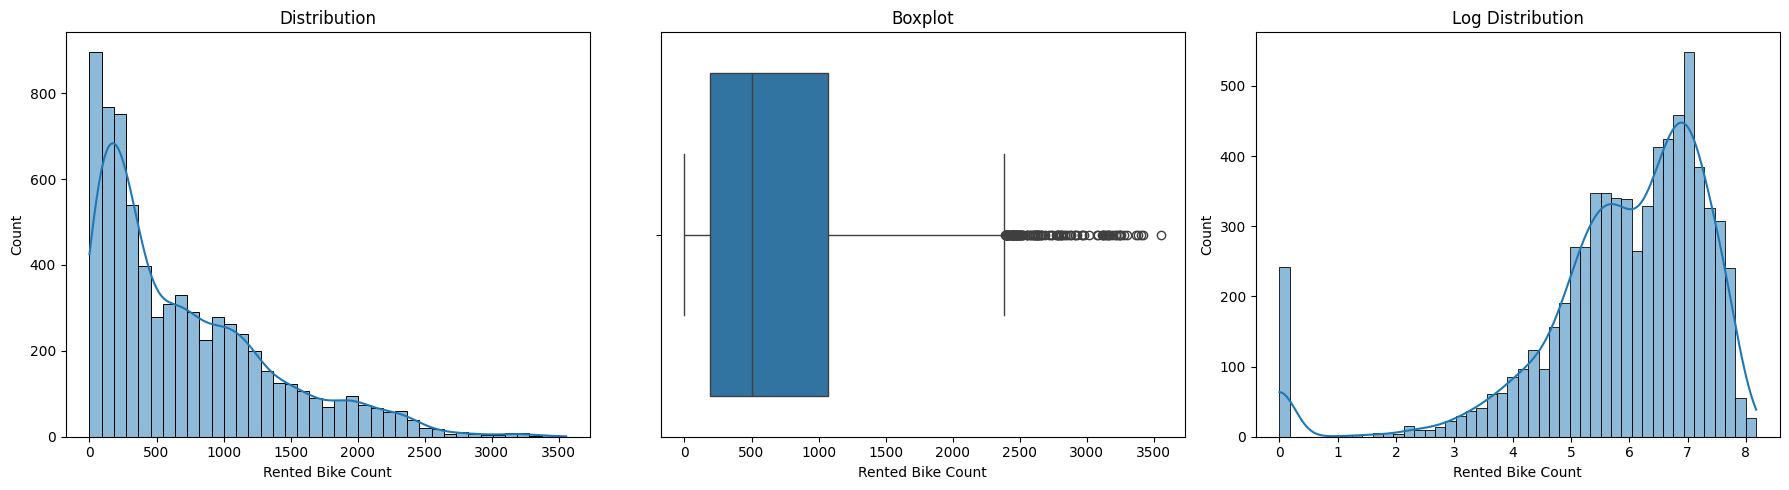

In [20]:
# Создадим графики распределения

y = df_train['Rented Bike Count']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram + KDE
sns.histplot(y, kde=True, ax=axes[0])
axes[0].set_title("Distribution")
axes[0].set_xlabel("Rented Bike Count")

# 2. Boxplot
sns.boxplot(x=y, ax=axes[1])
axes[1].set_title("Boxplot")

# 3. Log Distribution
sns.histplot(np.log1p(y), kde=True, ax=axes[2])
axes[2].set_title("Log Distribution")

plt.tight_layout()
plt.show()

Вывод: по графикам видно, что целевая переменная имеет ненормальное распределение с ассимметрией и выбросами, сильная правосторонняя скошенность

#### Графики зависимости целевой переменной от признаков

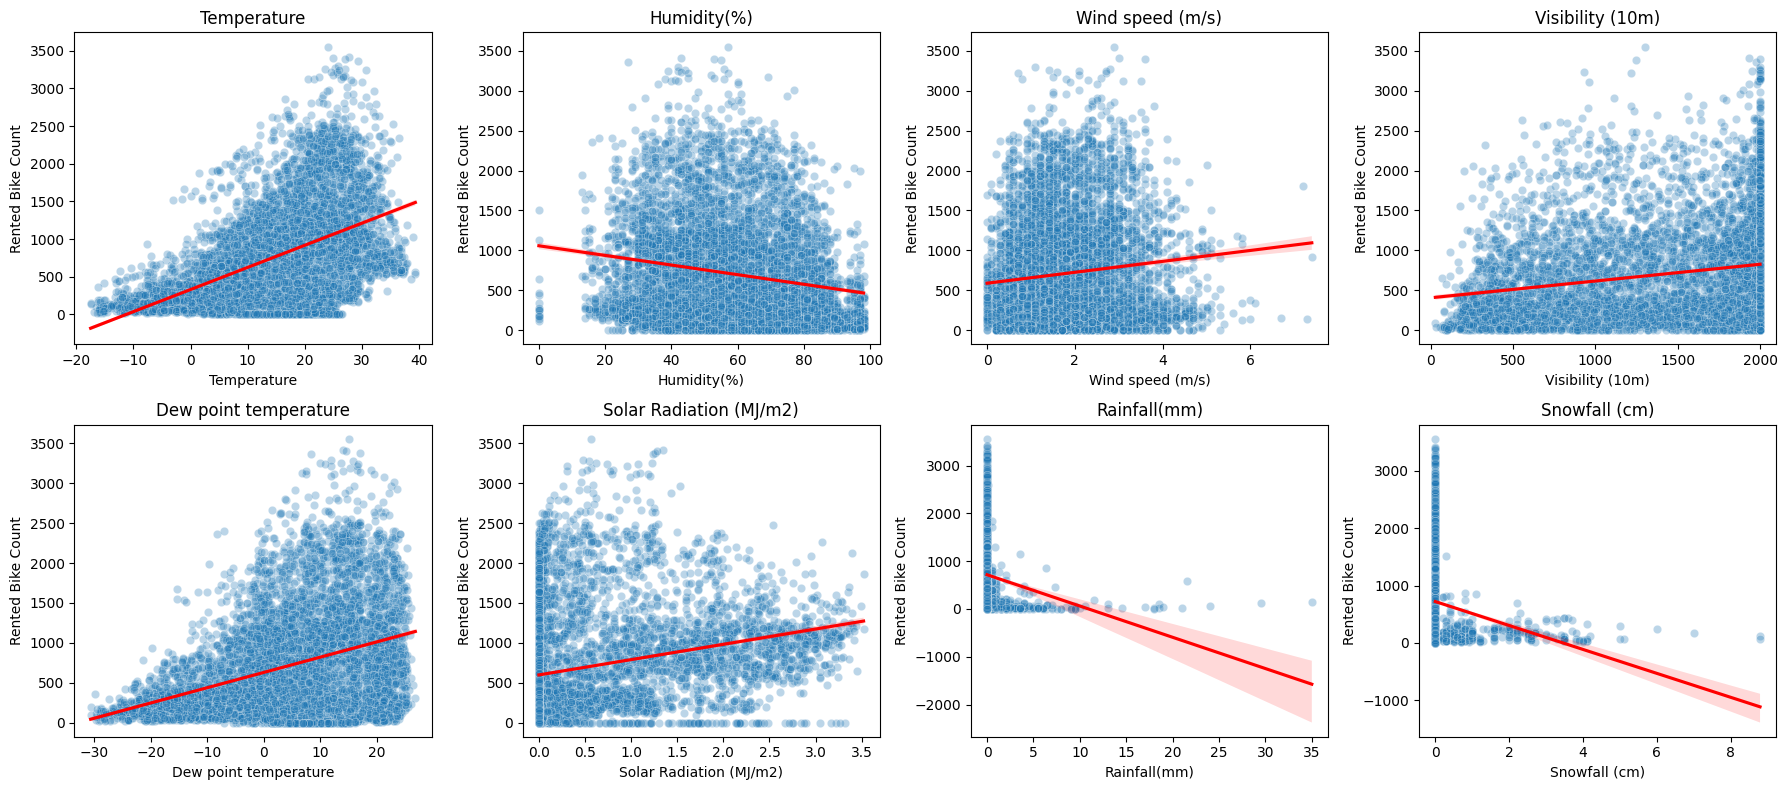

In [21]:
# Сначала определим числовые признаки и построим графики по ним

num_cols = [
    'Temperature', 'Humidity(%)', 'Wind speed (m/s)',
    'Visibility (10m)', 'Dew point temperature',
    'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(num_cols):
    row, col_idx = divmod(i, 4)
    
    sns.scatterplot(
        x=df_train[col],
        y=df_train['Rented Bike Count'],
        alpha=0.3,
        ax=axes[row, col_idx]
    )
    
    sns.regplot(
        x=df_train[col],
        y=df_train['Rented Bike Count'],
        scatter=False,
        color='red',
        ax=axes[row, col_idx]
    )
    
    axes[row, col_idx].set_title(col)

plt.tight_layout()
plt.show()

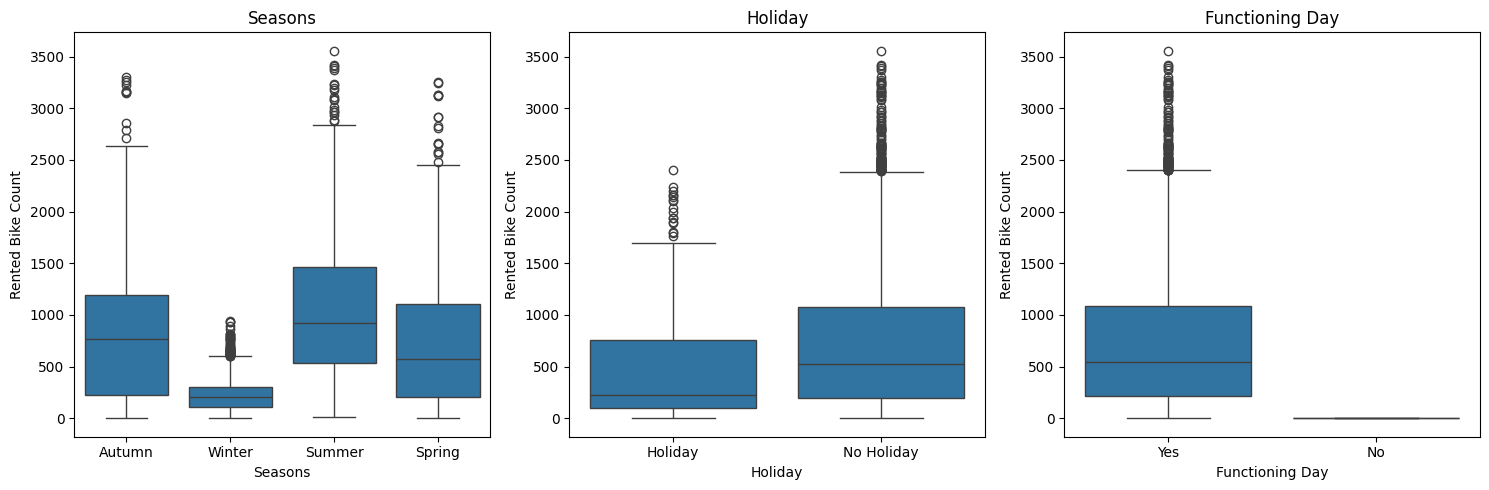

In [22]:
# Далее выделим категориальные признаки

cat_cols = ['Seasons', 'Holiday', 'Functioning Day']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cat_cols):
    sns.boxplot(
        x=df_train[col],
        y=df_train['Rented Bike Count'],
        ax=axes[i]
    )
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

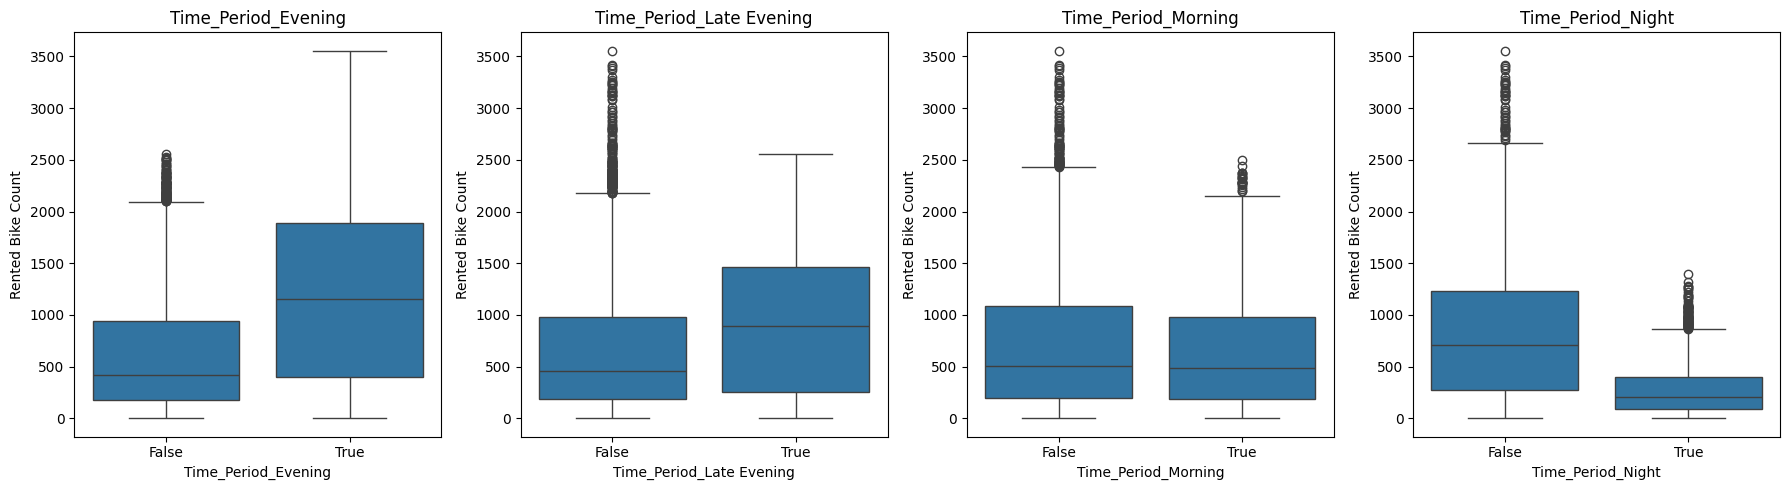

In [23]:
# Третьим этапом выведем графики зависимости от булевых признаков

bool_cols = [
    'Time_Period_Evening',
    'Time_Period_Late Evening',
    'Time_Period_Morning',
    'Time_Period_Night'
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(bool_cols):
    sns.boxplot(
        x=df_train[col],
        y=df_train['Rented Bike Count'],
        ax=axes[i]
    )
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

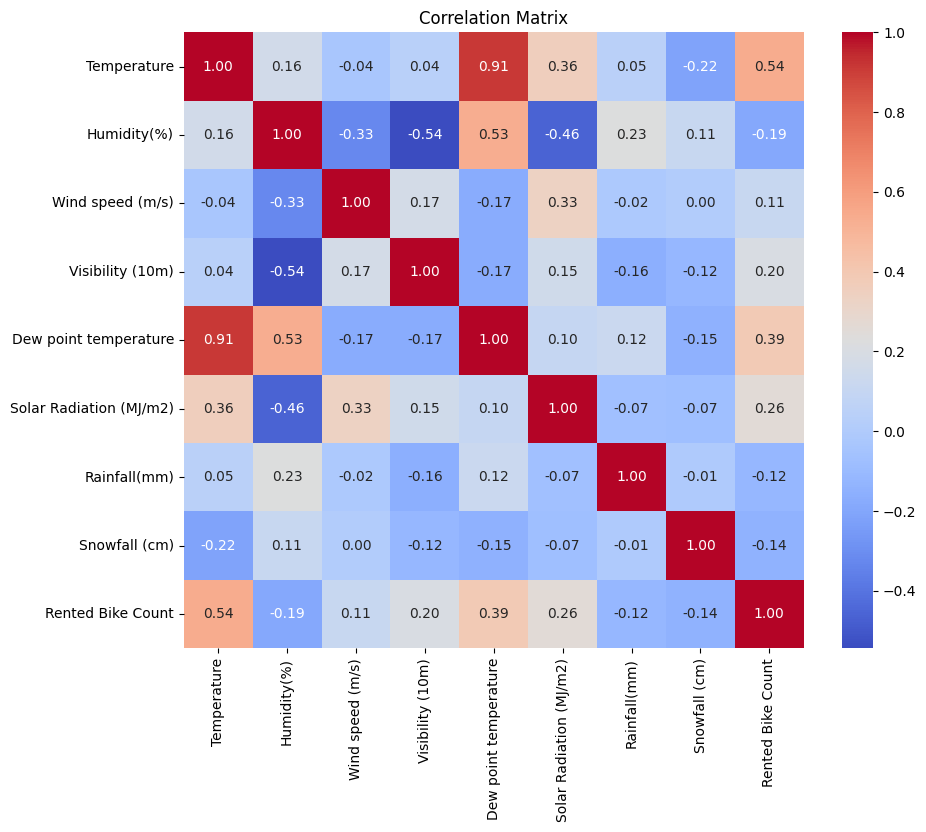

In [24]:
# Тепловая карта корелляций

plt.figure(figsize=(10, 8))

corr = df_train[num_cols + ['Rented Bike Count']].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

#### Сравнительный анализ спроса

Из полученных графиков можно сделать следующие выводы:

1. Спрос на аренду велосипедов имеет ярко выраженную сезонность: пик летом, минимум зимой.
2. Погодные условия — ключевой драйвер спроса (температура — самый сильный фактор, высокая влажность - спрос уменьшается, ветер практически не влияет на спрос, осадки - сильное падение спроса, снег - активность падает практически до нуля, "точка росы" мультиколлинеарна температуре, выше температура - выше спрос)
3. В праздничные дни наблюдается снижение спроса, что связано с уменьшением ежедневной мобильности пользователей
4. Признак Functioning Day: при неработающей системе спрос практически отсутствует

In [25]:
# Выведем статистику по признаку Functioning Day

df_train['Functioning Day'].value_counts(normalize=True)

Functioning Day
Yes    0.965468
No     0.034532
Name: proportion, dtype: float64

Таким образом, для дальнейшей работы оставим только 1 признак из двух мультиколлинеарных - Temperature. Также удалим признак Functioning Day - 97% сессий аренды совершены во время работы станций, признак просто учит модель if Functioning Day == "No" - predict = 0.

#### Расчет корелляции между признаками и целевой переменной

In [26]:
df_encoded = pd.get_dummies(df_train, drop_first=True)

corr = df_encoded.corr()
target_corr = corr['Rented Bike Count'].sort_values(ascending=False)

print(target_corr)

Rented Bike Count           1.000000
Temperature                 0.541478
Dew point temperature       0.386701
Time_Period_Evening         0.337953
Seasons_Summer              0.303390
Solar Radiation (MJ/m2)     0.256870
Functioning Day_Yes         0.206487
Visibility (10m)            0.197705
Time_Period_Late Evening    0.153632
Wind speed (m/s)            0.110949
Holiday_No Holiday          0.073979
Seasons_Spring              0.017407
Time_Period_Morning        -0.042484
Rainfall(mm)               -0.117923
Snowfall (cm)              -0.141062
Humidity(%)                -0.189910
Time_Period_Night          -0.372651
Seasons_Winter             -0.425483
Name: Rented Bike Count, dtype: float64


Таким образом можно сделать вывод: сильная корелляция с Temperature, средняя с Dew point temperature, Time_Period_Evening, Seasons_Summer, Solar Radiation. Отрицательная корелляция с признаками: Time_Period_Morning, Rainfall, Snowfall, Humidity, Time_Period_Night, Seasons_Winter

In [27]:
# По итогу предварительного исследования принято решение удалить 2 признака из обучающей и тестовой выборок

X_train_corr = X_train.drop(['Functioning Day', 'Dew point temperature'], axis=1)

X_test_corr = X_test.drop(['Functioning Day', 'Dew point temperature'], axis=1)

In [28]:
# Также посчитаем пропуски в признаках

X_train_corr.isna().sum()

Temperature                   0
Humidity(%)                 250
Wind speed (m/s)            210
Visibility (10m)            259
Solar Radiation (MJ/m2)     210
Rainfall(mm)                262
Snowfall (cm)               263
Seasons                       0
Holiday                       0
Time_Period_Evening           0
Time_Period_Late Evening      0
Time_Period_Morning           0
Time_Period_Night             0
dtype: int64

Выводы: 

1. По итогу предварительного анализа мы выявили мультиколлинеарность двух переменных: оставили для дальнейшей работы одну (Temperature)
2. Было выявлено, что присутствует переменная, которая практически на всем датасете имеет одинаковое значение - ее также удаляем, чтобы не искажать модель.
3. В нескольких переменных присутствуют пропуски: их количество менее 5% от выборки, в пайплайн необходимо будет добавить шаг по их заполнению медианными значениями.
4. По категориальным и булевским признакам пропусков нет

### Разделение выборки

In [29]:
# Разделим выборку X_train_corr на тренировочную и обучающую в соотношении 80% / 20%

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_corr, y_train, test_size=0.2, random_state=RANDOM_STATE
)

# Проверка

# Проверим разбивку
print(f"В обучающей выборке признаков {X_tr.shape[0]} значений")
print(f"В валидационной выборке тестовых признаков {X_val.shape[0]} значений")

print(f"В обучающей выборке по целевой переменной {y_tr.shape[0]} значений")
print(f"В валидационной выборке по целевой переменной {y_val.shape[0]} значений")

В обучающей выборке признаков 5606 значений
В валидационной выборке тестовых признаков 1402 значений
В обучающей выборке по целевой переменной 5606 значений
В валидационной выборке по целевой переменной 1402 значений


### Обучение новых моделей

#### Подготовка пайплайна (предобработка данных и инициализация моделей)

In [30]:
# Соберем признаки в переменные в зависимости от их типа

# Числовые 
num_features = [
    'Temperature', 'Humidity(%)', 'Wind speed (m/s)',
    'Visibility (10m)', 'Solar Radiation (MJ/m2)',
    'Rainfall(mm)', 'Snowfall (cm)'
]

# Категориальные

cat_features = ['Seasons', 'Holiday']

# Булевые

bool_features = [
    'Time_Period_Evening',
    'Time_Period_Late Evening',
    'Time_Period_Morning',
    'Time_Period_Night'
]

Препроцессинг:
1. Числовые: заполнить пропуски, масштабировать
2. Категории: заполнить пропуски, one-hot encoding
3. Булевые: оставляем как есть

In [31]:
# числовой pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())  
])

# категориальный pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# общий препроцессор
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features),
    ('bool', 'passthrough', bool_features)
])

In [32]:
# Инициализируем модели

knn_model = KNeighborsRegressor()

tree_model = DecisionTreeRegressor()

#### Настройка базовых параметров и проверка пайплайнов

In [33]:
# Модель KNN 

knn_model = KNeighborsRegressor(
    n_neighbors=5,          
    metric='minkowski',   
    p=2                   
)

In [34]:
# Модель Решающее дерево

tree_model = DecisionTreeRegressor(
    max_depth=10,         
    min_samples_split=20,  
    min_samples_leaf=10,  
    random_state=RANDOM_STATE
)

In [35]:
# Собираем пайплайны

knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', knn_model)
])

tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', tree_model)
])

In [36]:
# Проведем обучение и предсказание на тестовой выборке

knn_pipeline.fit(X_tr, y_tr)
tree_pipeline.fit(X_tr, y_tr)

# предсказания на обучающей
y_tr_pred_knn = knn_pipeline.predict(X_tr)

# предсказания на валидационной
y_val_pred_knn = knn_pipeline.predict(X_val)

# обучающая
y_tr_pred_tree = tree_pipeline.predict(X_tr)

# валидационная
y_val_pred_tree = tree_pipeline.predict(X_val)

In [37]:
# Рассчитаем целевые метрики: RMSE, R² и MAE на базовых настройках моделей. 
# Для этого используем функцию calculate_metrics

def calculate_metrics(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

# Метрики для KNN
knn_train_metrics = calculate_metrics(y_tr, y_tr_pred_knn)
knn_val_metrics = calculate_metrics(y_val, y_val_pred_knn)

# Метрики для дерева
tree_train_metrics = calculate_metrics(y_tr, y_tr_pred_tree)
tree_val_metrics = calculate_metrics(y_val, y_val_pred_tree)

# Соберем и выведем таблицу
results = pd.DataFrame([
    ["KNN", "Train", *knn_train_metrics.values()],
    ["KNN", "Validation", *knn_val_metrics.values()],
    ["Decision Tree", "Train", *tree_train_metrics.values()],
    ["Decision Tree", "Validation", *tree_val_metrics.values()],
], columns=["Model", "Dataset", "RMSE", "MAE", "R2"])

print(results.round(3))

           Model     Dataset     RMSE      MAE     R2
0            KNN       Train  304.497  199.151  0.779
1            KNN  Validation  389.570  254.922  0.633
2  Decision Tree       Train  309.231  202.162  0.772
3  Decision Tree  Validation  384.688  247.306  0.642


Выводы:

1. Обе модели показывают сопоставимое качество, однако Decision Tree демонстрирует немного лучшие результаты на валидационной выборке.
2. При этом обе модели имеют умеренное переобучение, что проявляется в разнице метрик между обучающей и валидационной выборками.
3. Decision Tree лучше справляется с задачей благодаря способности моделировать нелинейные зависимости и пороговые эффекты, характерные для погодных факторов.

### Подбор гиперпараметров с Optuna

In [38]:
# Определим функцию цели для Optuna для обоих моделей. 
# Согласно задаче, целевая метрика это RMSE, дополнительная MAE. В рамках кроссвалидации будем их минимизировать

# Функция для Решающего дерева

def objective_tree(trial):
    
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 50)
    }
    
    model = DecisionTreeRegressor(**params, random_state=42)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    scores = cross_validate(
        pipeline,
        X_tr,
        y_tr,
        cv=N_FOLDS,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error"
        }
    )
    
    return -np.mean(scores["test_rmse"])

In [39]:
# Функция цели для KNN

def objective_knn(trial):
    
    params = {
        "n_neighbors": trial.suggest_int("n_neighbors", 3, 30),
        "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
        "p": trial.suggest_int("p", 1, 2)
    }
    
    model = KNeighborsRegressor(**params)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    scores = cross_validate(
        pipeline,
        X_tr,
        y_tr,
        cv=N_FOLDS,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error"
        }
    )
    
    return -np.mean(scores["test_rmse"])

In [40]:
# Запускаем оптимизацию для моделей

# для дерева
study_tree = optuna.create_study(direction="minimize")
study_tree.optimize(objective_tree, n_trials=50, show_progress_bar=False)

# для KNN
study_knn = optuna.create_study(direction="minimize")
study_knn.optimize(objective_knn, n_trials=50, show_progress_bar=False)

[I 2026-04-06 22:27:20,779] A new study created in memory with name: no-name-6399b996-2cc1-4f6c-bd47-b22ad92e6bfe
[I 2026-04-06 22:27:20,869] Trial 0 finished with value: 376.23047895195305 and parameters: {'max_depth': 10, 'min_samples_split': 20, 'min_samples_leaf': 43}. Best is trial 0 with value: 376.23047895195305.
[I 2026-04-06 22:27:20,946] Trial 1 finished with value: 399.42745087982195 and parameters: {'max_depth': 5, 'min_samples_split': 41, 'min_samples_leaf': 24}. Best is trial 0 with value: 376.23047895195305.
[I 2026-04-06 22:27:21,019] Trial 2 finished with value: 397.78614993433814 and parameters: {'max_depth': 5, 'min_samples_split': 26, 'min_samples_leaf': 6}. Best is trial 0 with value: 376.23047895195305.
[I 2026-04-06 22:27:21,105] Trial 3 finished with value: 384.1403409234097 and parameters: {'max_depth': 10, 'min_samples_split': 38, 'min_samples_leaf': 4}. Best is trial 0 with value: 376.23047895195305.
[I 2026-04-06 22:27:21,188] Trial 4 finished with value: 37

In [41]:
# Сохраним и выведем лучшие параметры обоих моделей

best_tree_params = study_tree.best_params
best_knn_params = study_knn.best_params

best_tree_value = study_tree.best_value
best_knn_value = study_knn.best_value

print(f"Лучшие параметры модели Решающее дерево: {best_tree_params}, лучшее значение метрики: {best_tree_value}.")
print(f"Лучшие параметры модели KNN: {best_knn_params}, лучшее значение метрики: {best_knn_value}.")

Лучшие параметры модели Решающее дерево: {'max_depth': 13, 'min_samples_split': 28, 'min_samples_leaf': 28}, лучшее значение метрики: 373.72706656265655.
Лучшие параметры модели KNN: {'n_neighbors': 12, 'weights': 'distance', 'p': 1}, лучшее значение метрики: 360.9571350262991.


Вывод: в рамках подбора гиперпараметров с помощью Optuna удалось улучшить целевую метрику обоих моделей RMSE. Для дальнейшей работы будем использовать гиперпараметры, которые дают наилучший результат

### Кросс-валидация новых моделей

#### Кросс валидация

Кросс-валидация была проведена на этапе подобора гиперпараметров с Optuna. Потому в данном разделе просто сохраним лучшие модели и пайплайны

In [42]:
# лучшие модели
best_tree_model = DecisionTreeRegressor(
    **best_tree_params,
    random_state=RANDOM_STATE
)

best_knn_model = KNeighborsRegressor(
    **best_knn_params
)

# лучшие пайплайны
best_tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_tree_model)
])

best_knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_knn_model)
])

In [43]:
# Финальная проверка на тестовой выборке

best_tree_pipeline.fit(X_tr, y_tr)
best_knn_pipeline.fit(X_tr, y_tr)

y_test_knn_opt = best_knn_pipeline.predict(X_test_corr)
y_test_tree_pred = best_tree_pipeline.predict(X_test_corr)


final_results = pd.DataFrame([
    ['KNN Optimized', *calculate_metrics(y_test, y_test_knn_opt).values()],
    ['Decision Tree Optimized', *calculate_metrics(y_test, y_test_tree_pred).values()],
], columns=['Model', 'RMSE', 'MAE', 'R2'])

print(final_results.round(3))

                     Model     RMSE      MAE     R2
0            KNN Optimized  368.202  245.892  0.669
1  Decision Tree Optimized  361.108  237.623  0.681


Выводы:

1. Модель Решающее дерево показало чуть лучшие результаты, чем KNN на тестовой выборке
2. Показатели метрик на тестовой выборке сходны с показателями на кросс-валидации, потому обе модели можно считать стабильными
3. Показатели после подбора гиперпараметров улучшились в сравнении с базовыми параметрами моделей

#### Сравнение с baseline моделью

In [44]:
# Приведем baseline модель в тот же формат, что и результаты кросс валидации для составления сравнительной таблицы

baseline_summary = baseline_results[
    baseline_results['Dataset'] == 'Test'
][['RMSE', 'MAE', 'R2']].copy()

baseline_summary['Model'] = 'Baseline'

baseline_summary = baseline_summary[['Model', 'RMSE', 'MAE', 'R2']]

print(baseline_summary.round(3))

      Model     RMSE      MAE     R2
0  Baseline  411.564  312.599  0.586


In [45]:
# Объединяем 

comparison = pd.concat([baseline_summary, final_results], ignore_index=True)

print(comparison.round(3))

                     Model     RMSE      MAE     R2
0                 Baseline  411.564  312.599  0.586
1            KNN Optimized  368.202  245.892  0.669
2  Decision Tree Optimized  361.108  237.623  0.681


#### Выводы

1. После подбора гиперпараметров и проведения кросс-валидации качество моделей улучшилось по сравнению с baseline.
2. Проверка на валидационной выборке показала стабильность работы подготовленных моделей
3. Обе модели (KNN и Decision Tree) показали более низкие значения RMSE и MAE, а также более высокий R².
4. Решающее дерево продемонстрировало наилучшие значения метрик и меньший разброс результатов на кросс-валидации, что говорит о более стабильной работе модели.
5. KNN также показала улучшение по сравнению с baseline, однако немного уступает Решающему по целевой метрике

### Отчет по моделям

#### Сравнительная таблица и признаки

In [46]:
# Выведем результаты в виде таблицы

display(comparison)

,Model,RMSE,MAE,R2
0,Baseline,411.564089,312.599334,0.586072
1,KNN Optimized,368.201637,245.891602,0.668700
2,Decision Tree Optimized,361.107920,237.623179,0.681343


Посмотрим на признаки с точки зрения важности их для модели. Извлечем признаки из Decision Tree и отсортируем их по важности

In [47]:
# достаём обученное дерево из пайплайна
tree_model = best_tree_pipeline.named_steps['model']

# имена признаков после препроцессинга
feature_names = best_tree_pipeline.named_steps['preprocessor'].get_feature_names_out()

# важности
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': tree_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance_df.head(10))

                           feature  importance
0                 num__Temperature    0.410825
13       bool__Time_Period_Evening    0.160811
4     num__Solar Radiation (MJ/m2)    0.102698
14  bool__Time_Period_Late Evening    0.093582
1                 num__Humidity(%)    0.093051
7              cat__Seasons_Autumn    0.038152
5                num__Rainfall(mm)    0.035140
16         bool__Time_Period_Night    0.031872
8              cat__Seasons_Spring    0.012335
15       bool__Time_Period_Morning    0.008425


Выводы: 
1. Температура сильно влияет на спрос: в тёплую погоду велосипеды арендуют чаще.
2. Осадки и снег снижают спрос: в плохую погоду пользователи реже выбирают велосипед.
3. Время суток и сезон помогают модели ловить пиковые и низкие периоды спроса.

####  Визуализация 

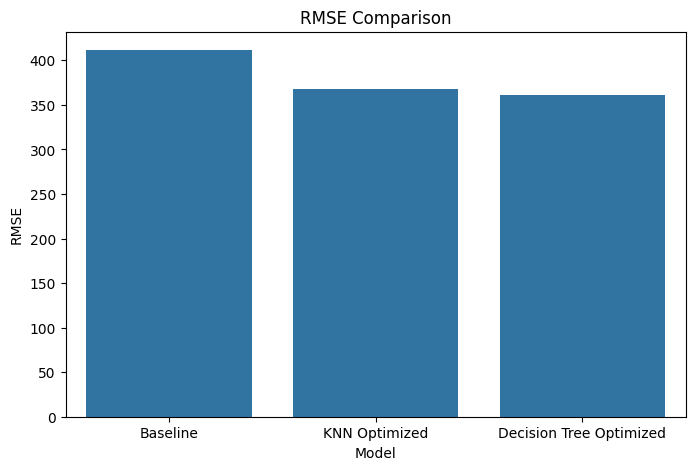

In [48]:
# RMSE

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison, x='Model', y='RMSE')
plt.title("RMSE Comparison")
plt.show()

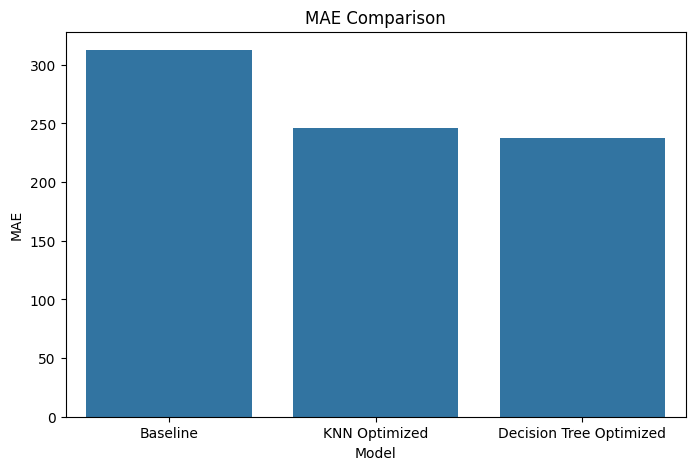

In [49]:
#MAE

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison, x='Model', y='MAE')
plt.title("MAE Comparison")
plt.show()

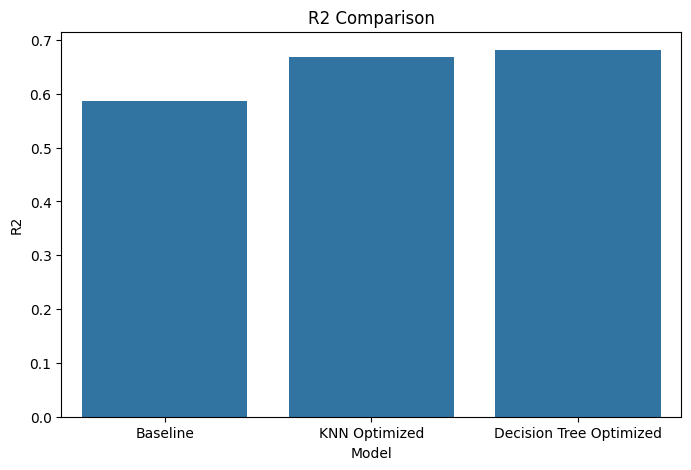

In [50]:
# R2

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison, x='Model', y='R2')
plt.title("R2 Comparison")
plt.show()

#### Выводы 

1. Модель Decision Tree показала наилучшие результаты по метрикам и может быть рекомендована как основная для прогнозирования спроса.
2. Анализ показал, что ключевыми факторами являются температура, погодные условия (дождь, снег, влажность) и время суток.
3. Спрос значительно возрастает в тёплую и солнечную погоду и резко снижается при осадках.
4. Полученные результаты могут быть использованы для оптимизации работы сервиса и более эффективного управления ресурсами.
5. Проводить технические работы в дни с низким спросом (например, при плохой погоде).

### Сохранение модели и отчета

#### Проверка лучшей модели на тестовой выборке

In [51]:
# Лучшей моделью является KNN (пайплайн с предобработкой данных)

best_model = best_knn_pipeline

# Применим его на тестовой выборке

y_test_pred = best_model.predict(X_test_corr)

# Расчет метрик

rmse_test, mae_test, r2_test = calculate_metrics(y_test, y_test_pred)

In [52]:
# Сохраняем в таблицу

knn_test_results = pd.DataFrame({
    'Model': ['Best model'],
    'RMSE': [rmse_test],
    'MAE': [mae_test],
    'R2': [r2_test]
})

print(knn_test_results.round(3))

        Model  RMSE  MAE  R2
0  Best model  RMSE  MAE  R2


Вывод: модель на тестовых данных показала сходные результаты, что говорит о ее стабильности. Данную модель можно рекомендовать для внедрения в продакшен

#### Сохранение результатов

In [53]:
# Собираем признаки
metadata = {
    'model_version': '1.0',
    'training_date': '2026-04-05',
    'features': X_tr.columns
}

In [54]:
# Сохраняем препроцессор и лучшую модель
joblib.dump({'preprocessor': preprocessor,
             'metadata': metadata,
             'best_model': best_model
            },
             'BikeSouth_model_1.0.joblib')

['BikeSouth_model_1.0.joblib']

In [55]:
# Загружаем модель для проверки

loaded_data = joblib.load('BikeSouth_model_1.0.joblib')

loaded_model = loaded_data['best_model']
loaded_preprocessor = loaded_data['preprocessor']

In [56]:
# Проверим применение загруженного препроцессора к тестовым данным

loaded_preprocessor.fit_transform(X_test_corr)

array([[-0.53764118, -0.50194969, -0.93473625, ...,  0.        ,
         0.        ,  0.        ],
       [-1.53589856,  1.58032937, -0.63415664, ...,  0.        ,
         1.        ,  0.        ],
       [-0.85375602,  0.39045562, -0.53396344, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-0.92862532,  1.43159515,  0.16738899, ...,  0.        ,
         0.        ,  0.        ],
       [-0.60419167,  0.34087755, -0.73434984, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.32751522, -0.35321547,  0.76854821, ...,  0.        ,
         0.        ,  0.        ]])

In [57]:
# Проверим предсказание загруженной модели на тестовых данных

loaded_model_predict = loaded_model.predict(X_test_corr)

# Рассчитаем основную метрику RMSE

RMSE_loaded = np.sqrt(mean_squared_error(y_test, loaded_model_predict))
print(round(RMSE_loaded, 4))

367.0333


Вывод: модель успешно сохранена и проверена на тестовых данных.

## Дополнительное задание

Добавим несколько признаков, которые являются бизнес-интерпретацией существующих в датафрейме
1. temp_humidity_interaction — температура × влажность
2. is_rainy — есть ли дождь
3. is_snowy — есть ли снег
4. bad_weather — дождь или снег
5. comfort_index — условный индекс комфортности

In [58]:
# Подготовим кастомный трансформер

class WeatherFeatureGenerator(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # взаимодействие температуры и влажности
        X['temp_humidity_interaction'] = X['Temperature'] * X['Humidity(%)']

        # бинарные погодные признаки
        X['is_rainy'] = (X['Rainfall(mm)'] > 0).astype(int)
        X['is_snowy'] = (X['Snowfall (cm)'] > 0).astype(int)
        X['bad_weather'] = ((X['Rainfall(mm)'] > 0) | (X['Snowfall (cm)'] > 0)).astype(int)

        # простой индекс комфортности
        X['comfort_index'] = X['Temperature'] - 0.1 * X['Humidity(%)']

        return X

In [59]:
# Проверим его работоспособность

feature_generator = WeatherFeatureGenerator()
X_tr_new = feature_generator.fit_transform(X_tr)

print(X_tr_new.info())
print(X_tr_new.columns)

<class 'pandas.DataFrame'>
Index: 5606 entries, 1741 to 860
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Temperature                5606 non-null   float64
 1   Humidity(%)                5414 non-null   float64
 2   Wind speed (m/s)           5437 non-null   float64
 3   Visibility (10m)           5409 non-null   float64
 4   Solar Radiation (MJ/m2)    5437 non-null   float64
 5   Rainfall(mm)               5399 non-null   float64
 6   Snowfall (cm)              5395 non-null   float64
 7   Seasons                    5606 non-null   str    
 8   Holiday                    5606 non-null   str    
 9   Time_Period_Evening        5606 non-null   bool   
 10  Time_Period_Late Evening   5606 non-null   bool   
 11  Time_Period_Morning        5606 non-null   bool   
 12  Time_Period_Night          5606 non-null   bool   
 13  temp_humidity_interaction  5414 non-null   float64
 14  is_rai

In [60]:
# Обновим списки признаков

num_features_ext = [
    'Temperature', 'Humidity(%)', 'Wind speed (m/s)',
    'Visibility (10m)', 'Solar Radiation (MJ/m2)',
    'Rainfall(mm)', 'Snowfall (cm)',
    'temp_humidity_interaction', 'is_rainy',
    'is_snowy', 'bad_weather', 'comfort_index'
]

cat_features = ['Seasons', 'Holiday']

bool_features = [
    'Time_Period_Evening',
    'Time_Period_Late Evening',
    'Time_Period_Morning',
    'Time_Period_Night'
]

In [61]:
# Обновим препроцессор

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_ext = ColumnTransformer([
    ('num', num_pipeline, num_features_ext),
    ('cat', cat_pipeline, cat_features),
    ('bool', 'passthrough', bool_features)
])

In [62]:
# Обновим пайплайн с лучшей моделью, используя кастомный трансформер

knn_custom_pipeline = Pipeline([
    ('feature_generator', WeatherFeatureGenerator()),
    ('preprocessor', preprocessor_ext),
    ('model', best_model.named_steps['model'])
])

In [63]:
# Проверим его на валидационной выборке и посчитаем метрики

# Обучение
knn_custom_pipeline.fit(X_tr, y_tr)

# Предсказание

y_val_pred_knn_custom = knn_custom_pipeline.predict(X_val)

# Метрики

rmse_val, mae_val, r2_val = calculate_metrics(y_val, y_val_pred_knn_custom).values()

In [64]:
# Выведем метрики

custom_knn_results = pd.DataFrame({
    'Dataset': ['Validation'],
    'RMSE': [rmse_val],
    'MAE': [mae_val],
    'R2': [r2_val]
})

display(custom_knn_results.round(3))

,Dataset,RMSE,MAE,R2
0,Validation,357.617,231.154,0.691


Вывод: 

Добавление новых признаков  помогло несколько улучшить модель - снизить ошибку на валидационном датасете и повысить R2

Общие выводы по проекту: 

1. В рамках нашего проекта было разработано две модели - Решающее дерево и KNN - для предсказания спроса на арендные велосипеды для нашего заказчика
2. Модели были проверены на обучающей выборке, был проведен подбор гиперпараметров для определения наилучшей конфигурации моделей
3. Была определена модель для дальнейшей работы на продакшн среде
4. Основные признаки, которые влияют на спрос: погодные условия (температура, солнечная активность, влажность). При этом также были выявлены признаки, которые снижают спрос на аренду (ночное время суток, осадки, зимний сезон).
5. Также был сделан вывод, что работы на станциях по прокату необходимо планировать по прогнозу погоды - при неблагоприятном - проводить обслуживание, это поможет снизить издержки от простоя
